In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169844575", h="3298dbabb7", width=700, height=450) 

In [3]:
# Load the data
from wrangle import clean_files
df = clean_files("./data/buenos-aires-real-estate-*.csv")  # <--- "./data/buenos-aires-real-estate-*.csv"
df.info()

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 350.2 KB


In [4]:
# Create the feature matrix
X = df[["surface_covered_in_m2"]]  # <--- df[["surface_covered_in_m2"]]

# Create the target vector
y = df["price_aprox_usd"]  # <--- df["price_aprox_usd"]

In [5]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # <--- X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4997
Test set size: 1250


In [6]:
y_mean = y_train.mean()  # <--- y_train.mean()
print("Mean house price:", y_mean)

Mean house price: 134635.8685691415


In [7]:
# Create predictions (all the same mean value) for the TEST set
y_pred_baseline = [y_mean] * len(y_test)

# Calculate Mean Absolute Error
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)  # <--- mean_absolute_error(y_test, y_pred_baseline)

print("Baseline MAE:", mae_baseline)

Baseline MAE: 44515.61274011767


In [8]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169844382", h="3298dbabb7", width=700, height=450) 

In [9]:
# Instantiate the model
model_lr = LinearRegression()  # <--- LinearRegression()

# Fit the model
model_lr.fit(X_train, y_train)  # <--- model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Generate predictions on training data
y_pred_train = model_lr.predict(X_train)  # <--- model_lr.predict(X_train)

# Calculate training metrics
mae_train = mean_absolute_error(y_train, y_pred_train)  # <--- mean_absolute_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)  # <--- root_mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)  # <--- r2_score(y_train, y_pred_train)

print(f"Training MAE: ${mae_train:,.2f}")
print(f"Training RMSE: ${rmse_train:,.2f}")
print(f"Training R²: {r2_train:.4f}")

Training MAE: $31,161.18
Training RMSE: $43,087.89
Training R²: 0.4791


In [11]:
# Generate predictions on test data
y_pred_test = X_test  # <--- model_lr.predict(X_test)

# Calculate test metrics
mae_test = mean_absolute_error(y_test, y_pred_test)  # <--- mean_absolute_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)  # <--- root_mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)  # <--- r2_score(y_test, y_pred_test)

print(f"Test MAE: ${mae_test:,.2f}")
print(f"Test RMSE: ${rmse_test:,.2f}")
print(f"Test R²: {r2_test:.4f}")

Test MAE: $132,636.10
Test RMSE: $144,575.70
Test R²: -5.3125


In [12]:
# Create comparison DataFrame
metrics_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [mae_train, rmse_train, r2_train],  # <--- mae_train, rmse_train, r2_train
    'Test': [mae_train, rmse_train, r2_train]  # <--- mae_test, rmse_test, r2_test
})

print(metrics_comparison)

# Calculate the difference
print(f"\nRMSE difference (Test - Train): ${rmse_test - rmse_train:,.2f}")

  Metric      Training          Test
0    MAE  31161.180943  31161.180943
1   RMSE  43087.894408  43087.894408
2     R²      0.479095      0.479095

RMSE difference (Test - Train): $101,487.81


In [13]:
intercept = model_lr.intercept_  # <--- model_lr.intercept_
coefficient = model_lr.coef_[0]  # <--- model_lr.coef_[0]

print(f"Intercept: ${intercept:,.2f}")
print(f"Coefficient: ${coefficient:,.2f} per square meter")

Intercept: $10,695.28
Coefficient: $2,282.21 per square meter


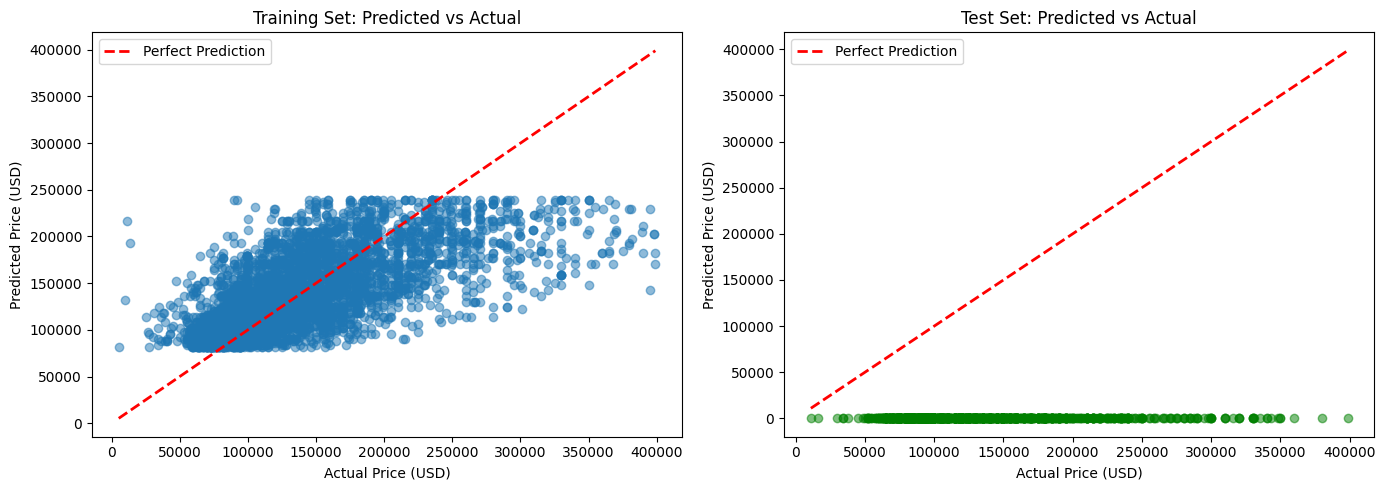

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Training Set: Predicted vs Actual')
axes[0].legend()

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title('Test Set: Predicted vs Actual')
axes[1].legend()

plt.tight_layout()

ValueError: x and y must be the same size

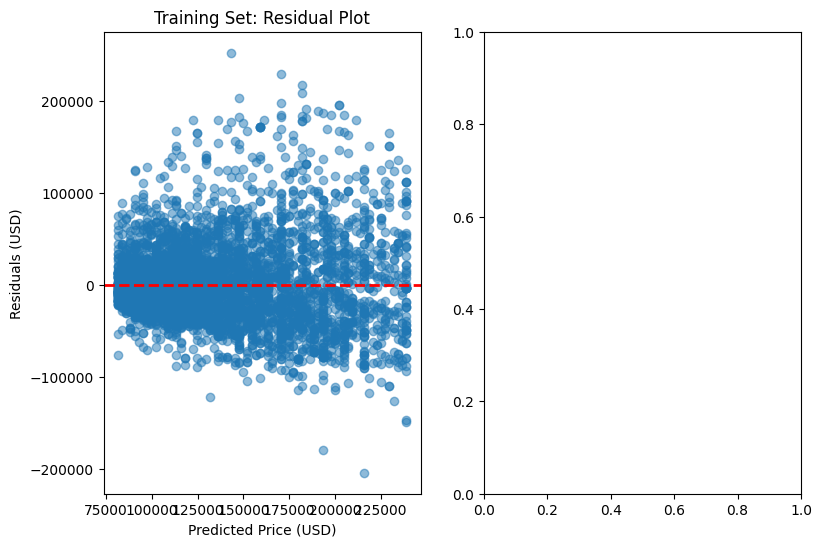

In [15]:
residuals_train = y_train - y_pred_train  # <--- y_train - y_pred_train
residuals_test = y_test - y_pred_test  # <--- y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Training residuals
axes[0].scatter(y_pred_train, residuals_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residuals (USD)')
axes[0].set_title('Training Set: Residual Plot')

# Test residuals
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Test Set: Residual Plot')

plt.tight_layout()

/usr/local/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


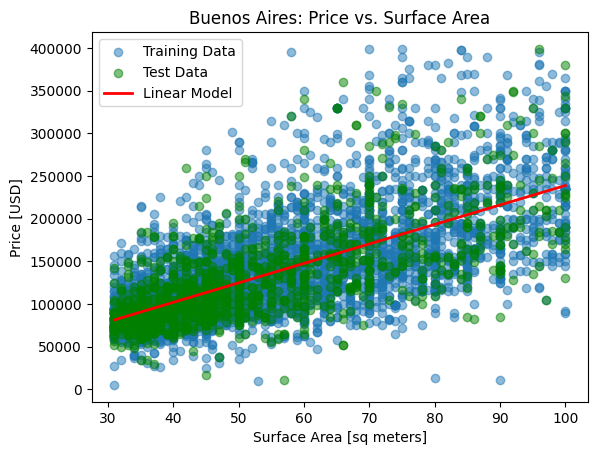

In [16]:
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, alpha=0.5, label='Training Data')
ax.scatter(X_test, y_test, alpha=0.5, color='green', label='Test Data')

# Create evenly-spaced x values for the line
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
ax.plot(x_line, model_lr.predict(x_line), color="red", linewidth=2, label="Linear Model")

ax.set_xlabel("Surface Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Buenos Aires: Price vs. Surface Area")
ax.legend()